Using a small seaborn dataset called "tips" and initializing the columns 'total_bill' , 'tip' and 'size'.


In [15]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

tips = sns.load_dataset("tips")
X = tips[['total_bill','size']].values
y = tips[['tip']].values
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
y_mean = y.mean()
y_std = y.std()
X = (X - X_mean) / X_std
y = (y - y_mean) / y_std

print(X.shape)


(244, 2)


Initializing network and biases , Neural network layers -> Input (2) --> Hidden (4) --> Output(1)

In [21]:
np.random.seed(42)

w1 = np.random.randn(2,4) * 0.01
b1 = np.zeros((1,4))
w2 = np.random.randn(4,1) * 0.01
b2 = np.zeros((1,1))


Implementing Manual Relu and MSE Functions

In [22]:
def relu(z):
    return np.maximum(0,z)

def mse(pred,y):
    return np.mean((pred-y)**2)

Starting training keeping steps = 2000 , alpha = 0.01

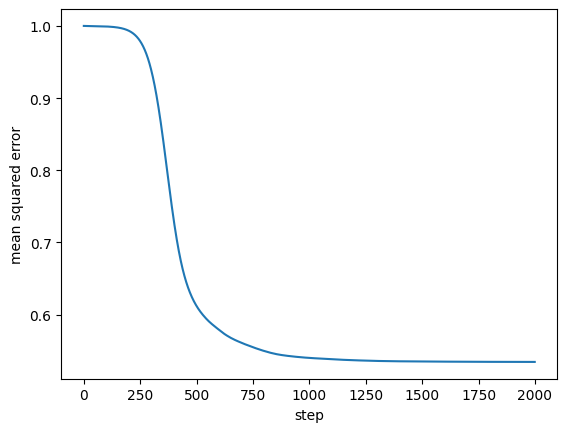

In [23]:
def train(X,y,w1,b1,w2,b2,alpha = 0.01, steps = 2000):
    samples = X.shape[0]
    history = []
    for i in range(steps):
        z1 = (X@w1)+b1
        a1 = relu(z1) #hidden layer
        pred = (a1@w2)+b2
        loss = mse(pred,y)
        dpred = (2/samples)*(pred-y)
        dw2 = (a1.T @ dpred)
        db2 = np.sum(dpred,axis = 0, keepdims = True)
        da1 = (dpred @ w2.T)
        dz1 = da1 * (z1>0)
        dw1 = (X.T @ dz1)
        db1 = np.sum(dz1, axis=0, keepdims=True)
        w1 -= alpha*dw1
        w2 -= alpha*dw2
        b1 -= alpha*db1
        b2 -= alpha*db2
        history.append(mse(pred,y))
    return history, w1, b1, w2, b2

history, w1, b1, w2, b2 = train(X, y, w1, b1, w2, b2)

plt.plot(history)
plt.xlabel("step"); plt.ylabel("mean squared error")
plt.show()


Cross checking the gradients with pytorch


In [33]:
import torch
def train(X,y,w1,b1,w2,b2,alpha = 0.01, steps = 2000):
    samples = X.shape[0]
    history = []
    for i in range(steps):
        z1 = (X@w1)+b1
        a1 = relu(z1) #hidden layer
        pred = (a1@w2)+b2
        loss = mse(pred,y)
        dpred = (2/samples)*(pred-y)
        dw2 = (a1.T @ dpred)
        db2 = np.sum(dpred,axis = 0, keepdims = True)
        da1 = (dpred @ w2.T)
        dz1 = da1 * (z1>0)
        dw1 = (X.T @ dz1)
        db1 = np.sum(dz1, axis=0, keepdims=True)
        w1 -= alpha*dw1
        w2 -= alpha*dw2
        b1 -= alpha*db1
        b2 -= alpha*db2
        history.append(mse(pred,y))

        if i == 0 :
            w1_t = torch.tensor(w1, dtype=torch.float32, requires_grad=True)
            b1_t = torch.tensor(b1, dtype=torch.float32, requires_grad=True)
            w2_t = torch.tensor(w2, dtype=torch.float32, requires_grad=True)
            b2_t = torch.tensor(b2, dtype=torch.float32, requires_grad=True)

            X_t = torch.tensor(X, dtype=torch.float32)
            y_t = torch.tensor(y, dtype=torch.float32)

            z1_t = torch.matmul(X_t, w1_t) + b1_t
            a1_t = torch.relu(z1_t)
            pred_t = torch.matmul(a1_t, w2_t) + b2_t
            loss_t = torch.mean((pred_t - y_t) ** 2)

            loss_t.backward()
            print("W1 match:", np.allclose(dw1, w1_t.grad.numpy(), atol=1e-2))
            print("b1 match:", np.allclose(db1, b1_t.grad.numpy(), atol=1e-2))
            print("W2 match:", np.allclose(dw2, w2_t.grad.numpy(), atol=1e-2))
            print("b2 match:", np.allclose(db2, b2_t.grad.numpy(), atol=1e-2))
            print("W1 max diff:", np.max(np.abs(dw1 - w1_t.grad.numpy())))
            print("b1 max diff:", np.max(np.abs(db1 - b1_t.grad.numpy())))
            print("W2 max diff:", np.max(np.abs(dw2 - w2_t.grad.numpy())))
            print("b2 max diff:", np.max(np.abs(db2 - b2_t.grad.numpy())))

train(X,y,w1,b1,w2,b2)


W1 match: True
b1 match: True
W2 match: True
b2 match: True
W1 max diff: 0.0031570275693416413
b1 max diff: 0.002771876712833434
W2 max diff: 3.4824022195033277e-06
b2 max diff: 1.3586922919736621e-05
